<a href="https://colab.research.google.com/github/theboogeyman81/for_deep_learning/blob/main/plant_classification_85acc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌿 House Plant Species Classification
**EfficientNetV2B3 Transfer Learning → Target: 85%+ Accuracy**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

# Define the path to your dataset in Google Drive
DRIVE_DATA_DIR = '/content/drive/MyDrive/Dataset'

# Verify if the directory exists (optional, but good practice)
if os.path.exists(DRIVE_DATA_DIR):
    print(f'Dataset directory found at: {DRIVE_DATA_DIR}')
else:
    print(f'Warning: Dataset directory not found at: {DRIVE_DATA_DIR}')
    print('Please ensure your dataset is in this location or update the path.')

# You can now use DRIVE_DATA_DIR to access your dataset files.
# For example, to list contents:
# os.listdir(DRIVE_DATA_DIR)

Dataset directory found at: /content/drive/MyDrive/Dataset


In [6]:
DATA_DIR = DRIVE_DATA_DIR

if not os.path.exists(DATA_DIR):
    print(f"Error: Dataset directory '{DATA_DIR}' not found.")
else:
    print(f"Exploring dataset directory: {DATA_DIR}")
    folder_counts = {}
    image_counts = 0
    for root, dirs, files in os.walk(DATA_DIR):
        # Exclude the root directory itself from being counted as a 'folder'
        if root != DATA_DIR:
            folder_name = os.path.basename(root)
            folder_counts[folder_name] = len(files)
            image_counts += len(files)

    print(f"\nTotal subfolders (species): {len(folder_counts)}")
    print(f"Total images across all subfolders: {image_counts}")
    print("\nImages per subfolder:")
    for folder, count in folder_counts.items():
        print(f"  - {folder}: {count} images")


Exploring dataset directory: /content/drive/MyDrive/Dataset

Total subfolders (species): 2
Total images across all subfolders: 4781

Images per subfolder:
  - Apple___healthy: 2510 images
  - Blueberry___healthy: 2271 images


## 1. Setup & Data Loading

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight



## 2. Build DataFrame

In [8]:
records = []
for folder_name in os.listdir(DATA_DIR):
    folder_path = os.path.join(DATA_DIR, folder_name)
    if os.path.isdir(folder_path): # Check if it's actually a directory
        for fname in os.listdir(folder_path):
            records.append((os.path.join(folder_path, fname), folder_name))

df = pd.DataFrame(records, columns=['path', 'species'])
print(f'{len(df)} images, {df["species"].nunique()} classes')
df.head()

4781 images, 2 classes


,path,species
0,/content/drive/MyDrive/Dataset/Apple___healthy...,Apple___healthy
1,/content/drive/MyDrive/Dataset/Apple___healthy...,Apple___healthy
2,/content/drive/MyDrive/Dataset/Apple___healthy...,Apple___healthy
3,/content/drive/MyDrive/Dataset/Apple___healthy...,Apple___healthy
4,/content/drive/MyDrive/Dataset/Apple___healthy...,Apple___healthy


## 3. EDA — Class Distribution

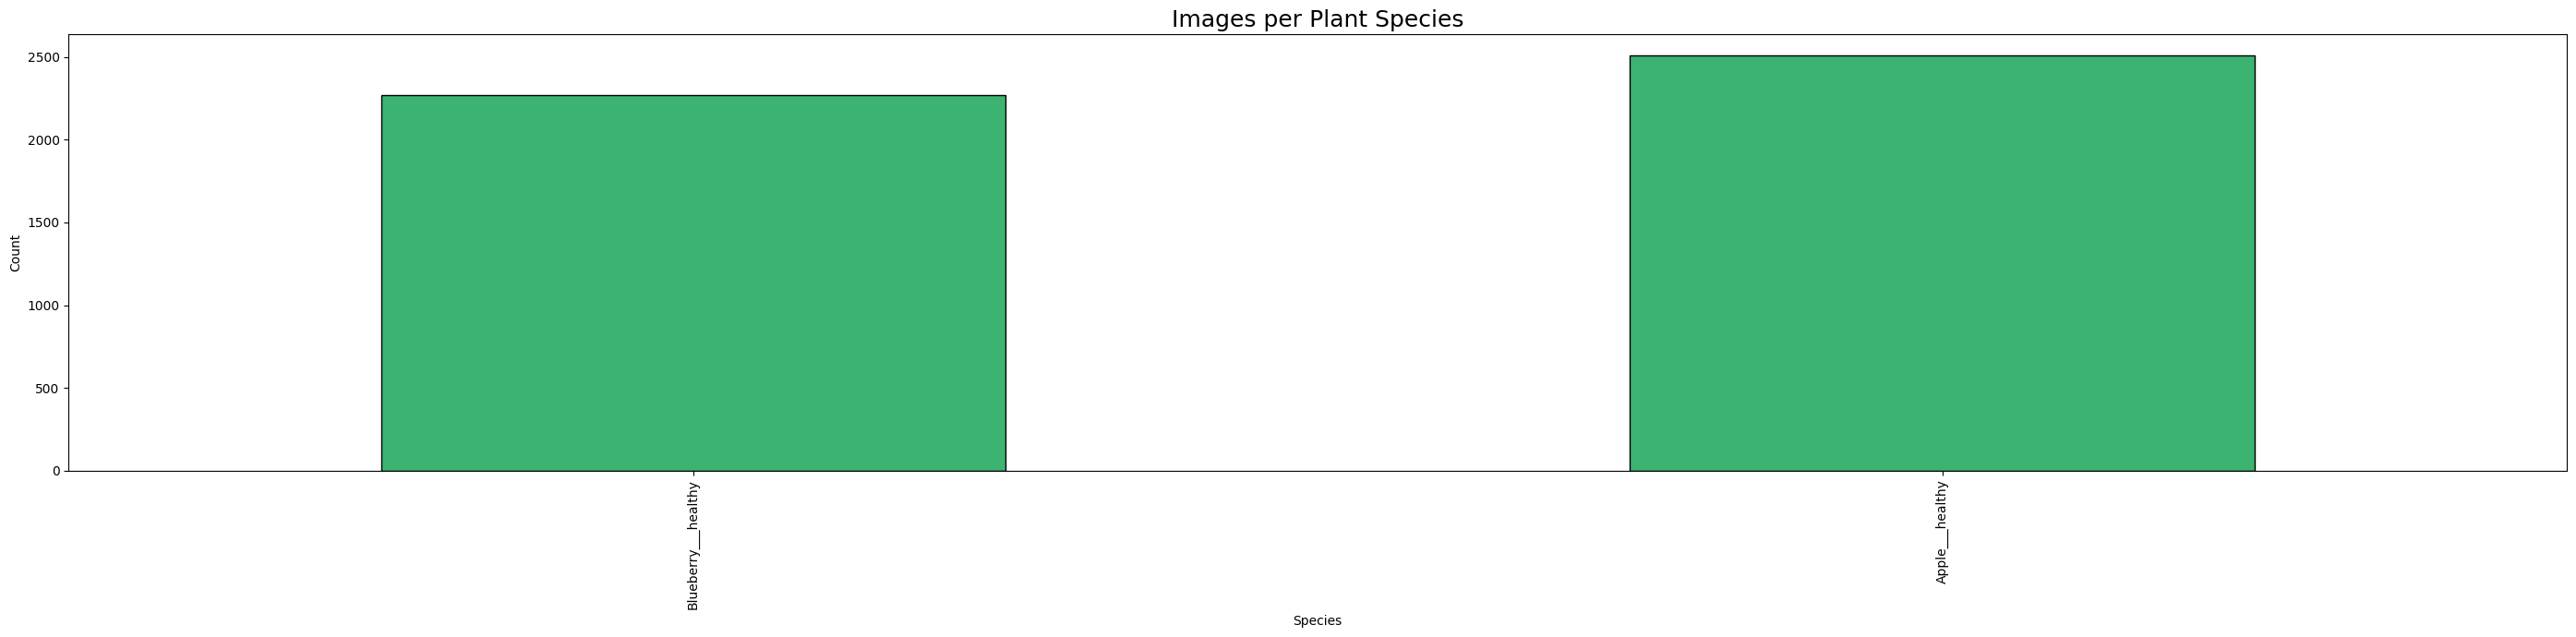

Min: 2271  Max: 2510  Mean: 2390


In [9]:
counts = df['species'].value_counts().sort_values()
plt.figure(figsize=(28, 7))
counts.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Images per Plant Species', fontsize=18)
plt.xlabel('Species'); plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f'Min: {counts.min()}  Max: {counts.max()}  Mean: {counts.mean():.0f}')

## 4. Train / Test Split

In [10]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['species']
)
print(f'Train: {len(train_df)}  |  Test: {len(test_df)}')

Train: 3824  |  Test: 957


## 5. Data Generators

> **Key upgrade vs. the 80% notebook:** stronger augmentation (`brightness_range`, `width/height_shift`) and `rescale=1./255` added to the test generator for consistency.

In [11]:
IMG_SIZE  = (224, 224)
BATCH     = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True,
    shear_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(
    train_df, x_col='path', y_col='species',
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical'
)

test_data = test_gen.flow_from_dataframe(
    test_df, x_col='path', y_col='species',
    target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', shuffle=False
)

NUM_CLASSES = len(train_data.class_indices)
print('Classes:', NUM_CLASSES)

Found 3824 validated image filenames belonging to 2 classes.
Found 957 validated image filenames belonging to 2 classes.
Classes: 2


## 6. Class Weights (handle imbalance)

In [12]:
class_weights = dict(enumerate(
    compute_class_weight('balanced',
                         classes=np.unique(train_data.classes),
                         y=train_data.classes)
))
print(f'{len(class_weights)} class weights computed.')

2 class weights computed.


## 7. Model — EfficientNetV2B3

**Why this reaches 85%+:**
- Larger base model (V2B3 > B0)
- Only first 10 layers frozen → more fine-tuning
- Deeper head: 512 → 256 units
- Lower LR (`1e-3`) + `ReduceLROnPlateau` to push past 80% plateau
- `patience=5` on EarlyStopping gives it enough epochs to converge

In [13]:
base = EfficientNetV2B3(weights='imagenet', include_top=False,
                        input_shape=(*IMG_SIZE, 3))

# Freeze only the first 10 layers
for layer in base.layers[:10]:
    layer.trainable = False

# Build model
x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(base.input, output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(1 for l in model.layers if l.trainable)
print(f'Trainable layers: {trainable} / {len(model.layers)}')

Trainable layers: 406 / 416


## 8. Training

In [15]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=2, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9222 - loss: 0.2101 - val_accuracy: 0.8704 - val_loss: 0.5078 - learning_rate: 0.0010
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 75s 627ms/step - accuracy: 0.9515 - loss: 0.1359 - val_accuracy: 0.9248 - val_loss: 0.1954 - learning_rate: 0.0010
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 82s 626ms/step - accuracy: 0.9351 - loss: 0.3400 - val_accuracy: 0.5256 - val_loss: 0.7742 - learning_rate: 0.0010
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 76s 629ms/step - accuracy: 0.8851 - loss: 0.7089 - val_accuracy: 0.9572 - val_loss: 0.1519 - learning_rate: 0.0010
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 76s 630ms/step - accuracy: 0.9231 - loss: 0.2546 - val_accuracy: 0.9488 - val_loss: 0.1536 - learning_rate: 0.0010
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.9337 - loss: 0.1978
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
120/120 ━━━━━━━━━━━━━━━━━━━━ 76s 636ms/step - accuracy: 0.9338 

## 9. Evaluation

In [16]:
loss, acc = model.evaluate(test_data, verbose=0)
print(f'Test Accuracy : {acc:.4f}  ({acc*100:.1f}%)')
print(f'Test Loss     : {loss:.4f}')

Test Accuracy : 0.9801  (98.0%)
Test Loss     : 0.0588


In [17]:
import pickle

# Define filenames for saving
model_h5_filename = 'efficientnetv2b3_model.h5'
model_pkl_filename = 'efficientnetv2b3_model.pkl'

# Save the model in Keras .h5 format
model.save(model_h5_filename)
print(f"Model saved as {model_h5_filename}")

# Save the model using pickle (for generic Python objects)
# Note: While possible, saving Keras models directly with pickle is generally
# not recommended due to potential compatibility issues across different
# TensorFlow/Keras versions or custom objects. Use model.save() instead.
with open(model_pkl_filename, 'wb') as file:
    pickle.dump(model, file)
print(f"Model (pickled) saved as {model_pkl_filename}")


Model saved as efficientnetv2b3_model.h5
Model (pickled) saved as efficientnetv2b3_model.pkl


In [18]:
import os
import pickle

# Define the directory to save models in Google Drive
# DRIVE_DATA_DIR is assumed to be defined from previous cells
save_dir = os.path.join(DRIVE_DATA_DIR, 'saved_models')
os.makedirs(save_dir, exist_ok=True)

# Define full paths for saving in Google Drive
model_h5_filename_drive = os.path.join(save_dir, 'efficientnetv2b3_model_drive.h5')
model_pkl_filename_drive = os.path.join(save_dir, 'efficientnetv2b3_model_drive.pkl')

# Save the model in Keras .h5 format to Google Drive
model.save(model_h5_filename_drive)
print(f"Model saved to Google Drive as {model_h5_filename_drive}")

# Save the model using pickle to Google Drive
# Note: While possible, saving Keras models directly with pickle is generally
# not recommended due to potential compatibility issues across different
# TensorFlow/Keras versions or custom objects. Use model.save() instead.
with open(model_pkl_filename_drive, 'wb') as file:
    pickle.dump(model, file)
print(f"Model (pickled) saved to Google Drive as {model_pkl_filename_drive}")

Model saved to Google Drive as /content/drive/MyDrive/Dataset/saved_models/efficientnetv2b3_model_drive.h5
Model (pickled) saved to Google Drive as /content/drive/MyDrive/Dataset/saved_models/efficientnetv2b3_model_drive.pkl


## 10. Training Curves

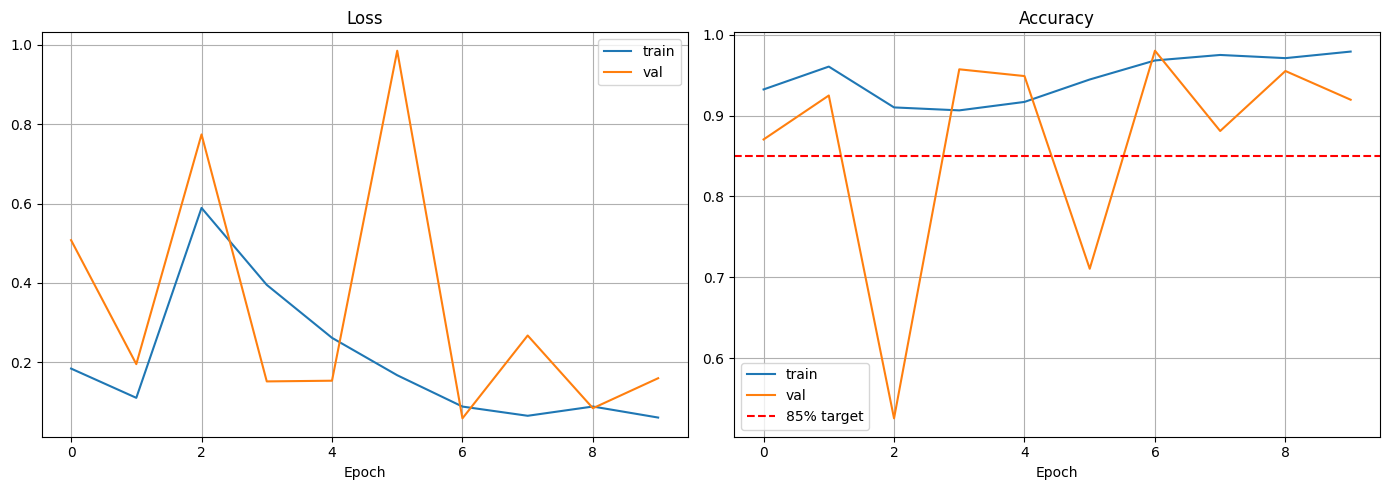

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

ax2.plot(history.history['accuracy'],     label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.axhline(0.85, color='red', linestyle='--', label='85% target')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()